<a href="https://colab.research.google.com/github/zeegy99/Quant_Backtesting_Models/blob/main/MACD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns



**Overarching Strategy:** The Moving Average Convergence Divergence (MACD) is a technical analysis tool that uses momentum to find opportunities to buy/sell. Academic Papers like Jegadesh & Titman (Implemented in a different repo, soon to be linked) have proved that momentum still works and I wanted to extend this to see if MACD also produces returns. We are looking at the exponential moving average and whenever it flips from positive to negative we sell, and when it flips from negative sentiment to positive sentiment we buy.

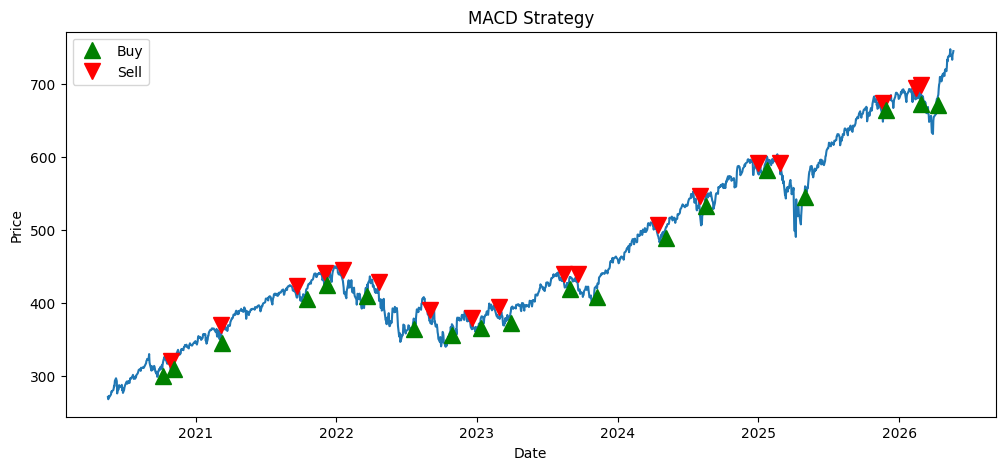

**Some Assumptions that are made: **

1. Buying and Selling are cut off such that they are 1:1 to not deal with the implications of Shorting & costs.  
2. Starting with 10,000 of capital, on a buy signal you will buy as much as you can and sell everything.

TODO/Additional Considerations
1. Adjusting the buy signal based on duration/intensity of switches
2. Trading costs are not incorporated
3. I assume we can easily short stocks without problem, and that the eventual buy pair cancels out the short leg.
4. How does this strategy perform during times of intense volatility?


**Findings:** During longer periods or periods of general growth, the sharpe and max drawdown significantly outperforms The s&p500. However, cumulative returns are less because we are not in the market during extended periods of time. Combined with a Bond/Money Market/ETF strategy this easily outperforms


However, during times of turbulence, MACD underperforms. [1999-2002, Cumulative return of -19.33% vs. -14.89%, Sharpe: -11.33 vs -0.15]

In [68]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def run_MACD(stock, start, end):
  import math
  start = start
  end = end


  def MACD(stock, start, end):
      #12-period EMA - 26-period EMA
      result = EMA(stock, 12, start, end) - EMA(stock, 26, start, end)
      return result


  def EMA(stock, period, start, end):

    #EMA Calculations based on articles
    df = yf.download(stock, start, end)
    df['SMA'] = df['Close'].rolling(period).mean()
    mult = 2 / (period + 1)

    ema_values = [np.nan] * len(df)

    for i in range(len(df)):
        close = df['Close'].iloc[i].item()
        sma   = df['SMA'].iloc[i].item()
        if math.isnan(sma):
            continue
        elif math.isnan(ema_values[i - 1]):
            ema_values[i] = sma
        else:
            ema_values[i] = ema_values[i - 1] * (1 - mult) + close * mult

    df['EMA'] = ema_values
    return df['EMA']


  #Plotting what MACD is
  df = MACD(stock, start, end).to_frame()
  df.name='MACD'

  df = df.rename(columns={'EMA': 'MACD'})

  plt.figure(figsize=(15, 7))
  plt.plot(df.index, df['MACD'])
  plt.title('MACD Graph')
  plt.show()


  #Cleaning MACD data so that we can determine when to buy/sell
  df['Clean'] = df['MACD'].fillna(-10)
  df['Buy'] = np.where(df['Clean'] > 0, 1, 0)

  Buy_list = []
  Sell_list = []
  in_position = False

  for i in range(len(df)):
      macd_today = df['MACD'].iloc[i]
      macd_yesterday = df['MACD'].iloc[i - 1]

      if math.isnan(macd_today) or math.isnan(macd_yesterday):
          continue

      if macd_today > 0 and macd_yesterday <= 0 and not in_position:
          Buy_list.append(i)
          in_position = True

      elif macd_today < 0 and macd_yesterday >= 0 and in_position:
          Sell_list.append(i)
          in_position = False

  print("Buy signals:", len(Buy_list))
  print("Sell signals:", len(Sell_list))

  fig, ax = plt.subplots(figsize=(12, 5))

  baseline = yf.download(ticker, start, end)
  ax.plot(baseline.index, baseline['Close'])

  buy_dates  = baseline.index[Buy_list]
  buy_prices = baseline['Close'].iloc[Buy_list]

  sell_dates = baseline.index[Sell_list]
  sell_prices = baseline['Close'].iloc[Sell_list]
  ax.plot(buy_dates, buy_prices - 15, '^', markersize=12, color='green', zorder=5, label='Buy')
  ax.plot(sell_dates, sell_prices + 15, 'v', markersize=12, color='red', label='Sell')
  plt.legend()
  plt.title("MACD Strategy")
  plt.xlabel("Date")
  plt.ylabel("Price")
  plt.show()

  capital = 10000  # starting capital, arbitrary.
  #Assumptions is that you are max-buying.
  equity = [capital]
  lesser = min(len(Buy_list), len(Sell_list))
  for i in range(lesser):
      buy_price  = baseline['Close'].iloc[Buy_list[i]].item()
      sell_price = baseline['Close'].iloc[Sell_list[i]].item()

      shares = capital // buy_price


      capital += shares * (sell_price - buy_price)
      equity.append(capital)


  equity = np.array(equity)


  total_return = (equity[-1] - equity[0]) / equity[0]
  trade_returns = np.diff(equity) / equity[:-1]

  sharpe       = trade_returns.mean() / trade_returns.std() * np.sqrt(252)
  rolling_max  = np.maximum.accumulate(equity)
  max_drawdown = ((equity - rolling_max) / rolling_max).min()

  print(f"Final Capital: ${equity[-1]:,.2f}")
  print(f"Total Return:  {total_return:.2%}")
  print(f"Sharpe:        {sharpe:.2f}")
  print(f"Max Drawdown:  {max_drawdown:.2%}")


#Final Graph
  for i in range(min(5, lesser)):
      buy_price  = baseline['Close'].iloc[Buy_list[i]].item()
      sell_price = baseline['Close'].iloc[Sell_list[i]].item()
      print(f"Trade {i+1}: Buy @ {buy_price:.2f} on {baseline.index[Buy_list[i]].date()}, Sell @ {sell_price:.2f} on {baseline.index[Sell_list[i]].date()}")

  plt.plot(equity)
  plt.title('Equity Curve')
  plt.xlabel('Trade #')
  plt.ylabel('Capital ($)')
  plt.show()



  #Comparison to SPY over timeframe
  spy = yf.download('SPY', start, end)

  spy_return = (spy['Close'].iloc[-1].item() - spy['Close'].iloc[0].item()) / spy['Close'].iloc[0].item()

  spy_daily_returns = spy['Close'].pct_change().dropna()
  spy_sharpe = (spy_daily_returns.mean() / spy_daily_returns.std() * np.sqrt(252)).item()

  print(f"SPY Total Return: {spy_return:.2%}")
  print(f"SPY Sharpe:       {spy_sharpe:.2f}")


  print(f"\n{'':20} {'Your Strategy':>15} {'SPY':>10}")
  print(f"{'Total Return':20} {total_return:>15.2%} {spy_return:>10.2%}")
  print(f"{'Sharpe':20} {sharpe:>15.2f} {spy_sharpe:>10.2f}")


/tmp/ipykernel_56392/2970912336.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_56392/2970912336.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


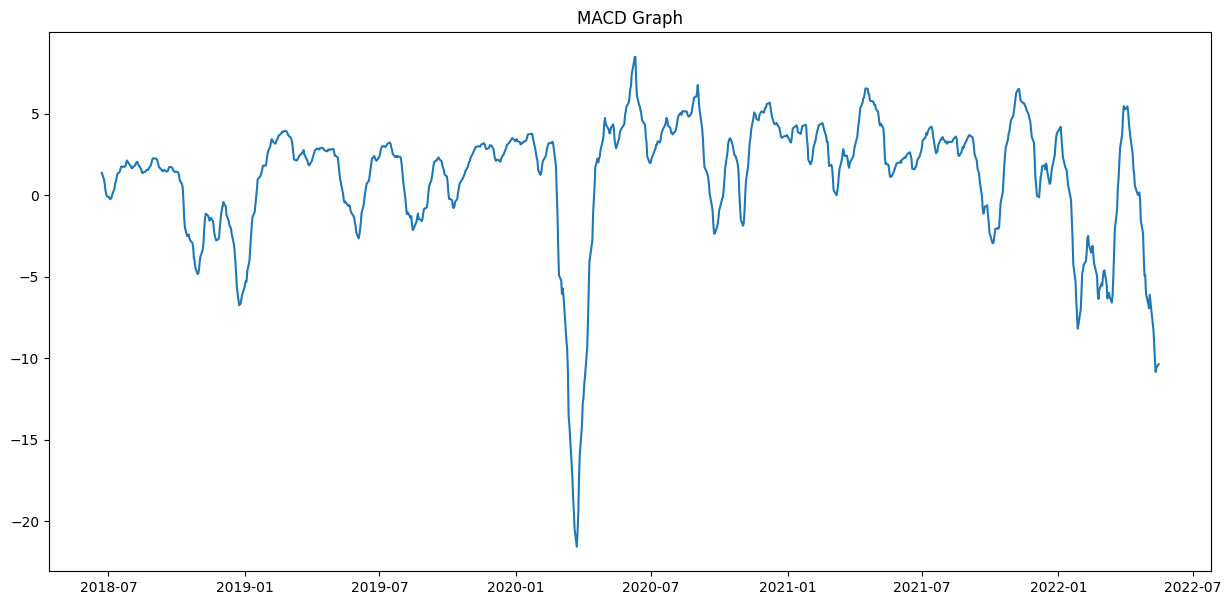

/tmp/ipykernel_56392/2970912336.py:79: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed

Buy signals: 12
Sell signals: 12


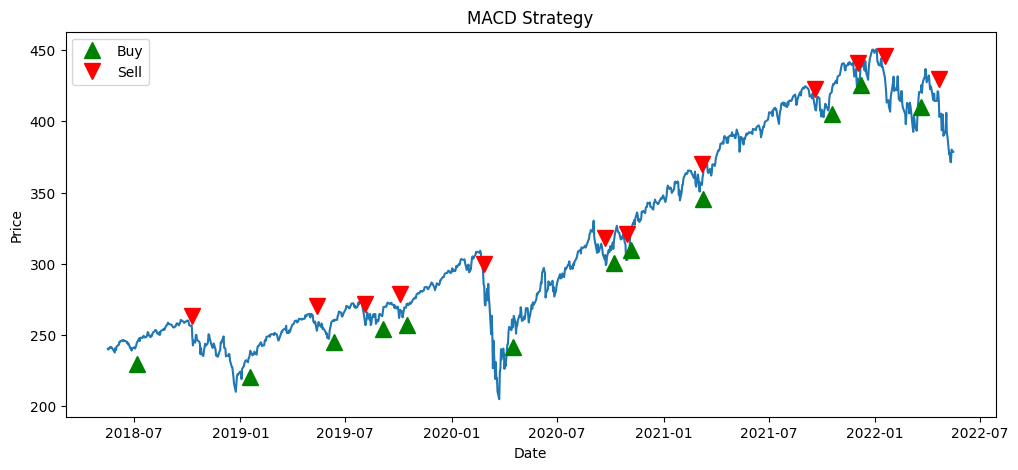

Final Capital: $15,220.91
Total Return:  52.21%
Sharpe:        9.01
Max Drawdown:  -4.62%
Trade 1: Buy @ 244.48 on 2018-07-06, Sell @ 248.15 on 2018-10-10
Trade 2: Buy @ 235.84 on 2019-01-17, Sell @ 255.30 on 2019-05-14
Trade 3: Buy @ 259.79 on 2019-06-12, Sell @ 256.92 on 2019-08-05
Trade 4: Buy @ 269.59 on 2019-09-05, Sell @ 264.11 on 2019-10-03
Trade 5: Buy @ 271.80 on 2019-10-15, Sell @ 284.67 on 2020-02-26


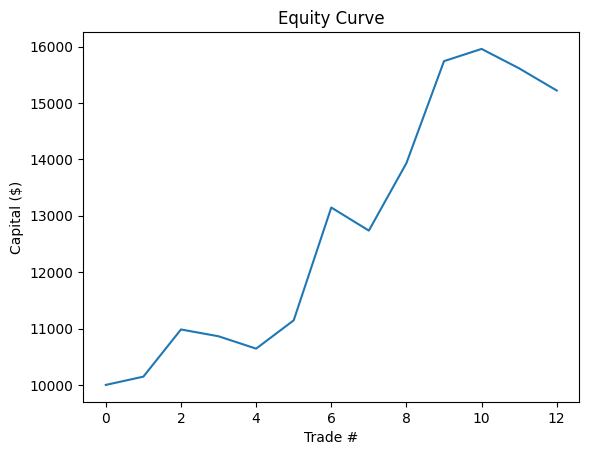

/tmp/ipykernel_56392/2970912336.py:141: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start, end)
[*********************100%***********************]  1 of 1 completed

SPY Total Return: 57.50%
SPY Sharpe:       0.64

                       Your Strategy        SPY
Total Return                  52.21%     57.50%
Sharpe                          9.01       0.64


In [69]:
ticker = 'SPY'
start = datetime(2018, 5, 17)
end = datetime(2022, 5, 17)
run_MACD(ticker, start, end)